# CSE153 Assignment 2: Symbolic Music Generation

**Dataset:** Nottingham Folk Music Database  
**Tasks:**
- **Task 1 — Symbolic Unconditioned Generation:** Train a model that learns a distribution over melodies and generates new ones from scratch.
- **Task 2 — Symbolic Conditioned Generation (Harmonization):** Given a melody, generate a matching chord accompaniment.

Both tasks use the same dataset and share a common preprocessing pipeline. We treat both as sequence modeling problems over symbolic note/chord tokens.

We follow these steps for each task:
1. Define the task and evaluation setup
2. Explore and preprocess the data
3. Build and train models
4. Evaluate and compare against baselines
5. Discuss results and related work

## Setup

In [1]:
!pip install music21 pretty_midi torch -q
!apt-get install -y fluidsynth > /dev/null 2>&1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 56.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.0 MB/s eta 0:00:00


In [2]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import pretty_midi

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
!git clone https://github.com/jukedeck/nottingham-dataset.git 2>/dev/null || echo 'Already cloned'

# The actual MIDI files are at the root of the repo's midi folder
import os

# Try a few possible paths
for candidate in [
    'nottingham-dataset/data/midi',
    'nottingham-dataset/midi',
    'nottingham-dataset',
]:
    if os.path.isdir(candidate):
        DATA_DIR = candidate
        break

midi_files = [
    os.path.join(root, f)
    for root, dirs, files in os.walk(DATA_DIR)
    for f in files
    if f.endswith('.mid') or f.endswith('.midi')
]
print(f'Found {len(midi_files)} MIDI files')

Found 3089 MIDI files


---
# Task 1: Symbolic Unconditioned Generation

**Task:** Train a model that learns a distribution over folk melodies p(x) and generates new melodies by sampling from it — no input required.

**Formulation:** We treat this as a **language modeling** problem. Each note is a token; we train an LSTM to predict the next token given all previous tokens. At generation time we sample autoregressively.

**Evaluation:**
- **Perplexity** on held-out sequences (lower = better; a uniform random model has PPL = vocabulary size)
- **Pitch class histogram overlap** between real and generated melodies
- **Average interval size** (large intervals = jumpy, unmusical melody)
- **Unique 3-gram ratio** (diversity measure — catches memorization)

## 1. Exploratory Analysis and Preprocessing

The **Nottingham Music Database** is a collection of ~1000 British and American folk tunes, widely used as a benchmark for symbolic music generation (Boulanger-Lewandowski et al. 2012, Sturm et al. 2016). The MIDI version contains melody and chord tracks extracted from ABC notation files.

We represent each note as a token of the form `p{pitch}_d{duration}`, e.g. `p60_d0.5` = middle C held for half a beat. Duration is quantized to the nearest standard rhythmic value.

In [4]:
def quantize_duration(dur_sec, bpm=120, bins=[0.125, 0.25, 0.5, 1.0, 2.0]):
    """Snap a duration in seconds to the nearest rhythmic bin (in beats)."""
    beat = 60.0 / bpm
    return min(bins, key=lambda b: abs(b - dur_sec / beat))

def midi_to_tokens(path):
    """Parse a MIDI file and return a list of 'p{pitch}_d{dur}' tokens."""
    try:
        pm = pretty_midi.PrettyMIDI(path)
        track = next((i for i in pm.instruments if not i.is_drum), None)
        if track is None or len(track.notes) < 5:
            return []
        bpm = pm.estimate_tempo()
        tokens = []
        for n in sorted(track.notes, key=lambda x: x.start):
            dur = quantize_duration(n.end - n.start, bpm)
            tokens.append(f'p{n.pitch}_d{dur}')
        return tokens
    except:
        return []

all_sequences = [s for f in midi_files if len(s := midi_to_tokens(f)) > 10]
print(f'Parsed {len(all_sequences)} melodies')
print(f'Example (first 10 tokens): {all_sequences[0][:10]}')

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Parsed 3059 melodies
Example (first 10 tokens): ['p66_d1.0', 'p67_d1.0', 'p69_d2.0', 'p66_d1.0', 'p67_d1.0', 'p69_d2.0', 'p66_d1.0', 'p67_d1.0', 'p69_d2.0', 'p78_d1.0']


=== Dataset Statistics ===
Melodies:          3059
Total tokens:      550720
Vocabulary size:   204
Avg melody length: 180.0 tokens
Pitch range:       MIDI 36-88
Duration counts:   [(1.0, 359940), (2.0, 99024), (0.5, 89805), (0.25, 1923), (0.125, 28)]


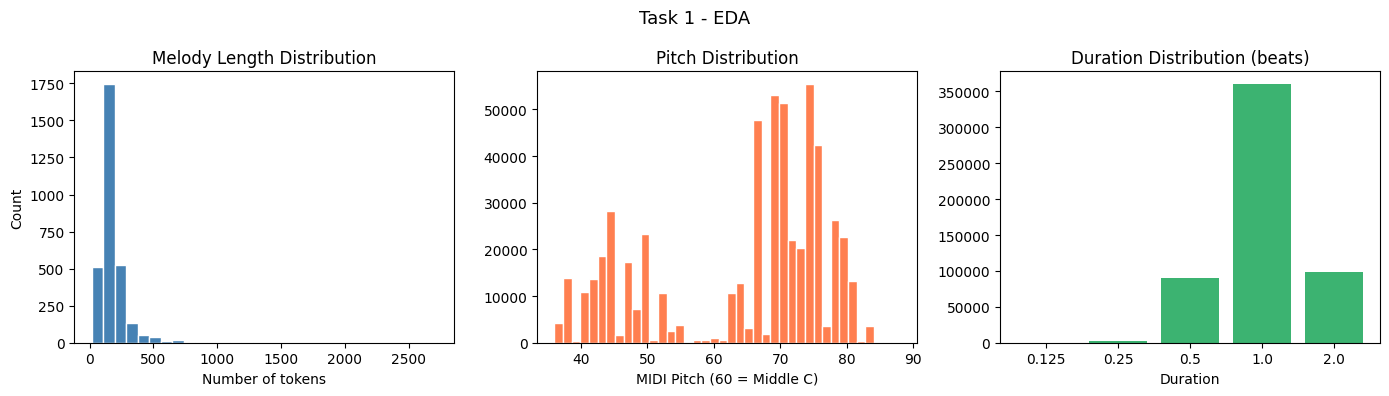

In [5]:
seq_lengths = [len(s) for s in all_sequences]
all_tokens  = [t for s in all_sequences for t in s]
all_pitches = [int(t.split('_')[0][1:]) for t in all_tokens]
all_durs    = [float(t.split('_d')[1]) for t in all_tokens]
vocab       = sorted(set(all_tokens))

print('=== Dataset Statistics ===')
print(f'Melodies:          {len(all_sequences)}')
print(f'Total tokens:      {len(all_tokens)}')
print(f'Vocabulary size:   {len(vocab)}')
print(f'Avg melody length: {np.mean(seq_lengths):.1f} tokens')
print(f'Pitch range:       MIDI {min(all_pitches)}-{max(all_pitches)}')
print(f'Duration counts:   {Counter(all_durs).most_common()}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(seq_lengths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Melody Length Distribution')
axes[0].set_xlabel('Number of tokens'); axes[0].set_ylabel('Count')
axes[1].hist(all_pitches, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Pitch Distribution')
axes[1].set_xlabel('MIDI Pitch (60 = Middle C)')
dur_counts = Counter(all_durs)
axes[2].bar([str(k) for k in sorted(dur_counts)], [dur_counts[k] for k in sorted(dur_counts)], color='mediumseagreen')
axes[2].set_title('Duration Distribution (beats)')
axes[2].set_xlabel('Duration')
plt.suptitle('Task 1 - EDA', fontsize=13)
plt.tight_layout()
plt.savefig('task1_eda.png', dpi=120)
plt.show()

## 2. Modeling

We model melody generation as **next-token prediction**: given tokens x1...xt, predict xt+1. The model learns p(xt+1 | x1...xt) and is trained with cross-entropy loss.

**Why LSTM?**
- An n-gram / Markov model only conditions on a fixed recent window — it misses longer-range structure like repeated phrases
- An LSTM maintains a hidden state that can capture longer dependencies, making it better suited for melody
- A Transformer would also work but requires more data and compute; LSTM is a reasonable choice for this dataset size

**Architecture:** Embedding → 2-layer LSTM with dropout → Linear output layer

In [6]:
PAD, SOS, EOS = '<PAD>', '<SOS>', '<EOS>'
vocab_list = [PAD, SOS, EOS] + vocab
tok2idx = {t: i for i, t in enumerate(vocab_list)}
idx2tok = {i: t for t, i in tok2idx.items()}
VOCAB_SIZE = len(vocab_list)
print(f'Vocabulary size (with special tokens): {VOCAB_SIZE}')

def encode(seq):
    return [tok2idx[SOS]] + [tok2idx[t] for t in seq if t in tok2idx] + [tok2idx[EOS]]

Vocabulary size (with special tokens): 207


In [7]:
SEQ_LEN = 32

class MelodyDataset(Dataset):
    """Sliding window over encoded sequences; target is input shifted by 1."""
    def __init__(self, sequences):
        self.samples = []
        for seq in sequences:
            for i in range(len(seq) - SEQ_LEN):
                x = torch.tensor(seq[i:i+SEQ_LEN])
                y = torch.tensor(seq[i+1:i+SEQ_LEN+1])
                self.samples.append((x, y))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

encoded = [encode(s) for s in all_sequences]
random.shuffle(encoded)
split = int(0.9 * len(encoded))
train_dl = DataLoader(MelodyDataset(encoded[:split]),  batch_size=64, shuffle=True)
val_dl   = DataLoader(MelodyDataset(encoded[split:]), batch_size=64)
print(f'Train batches: {len(train_dl)}, Val batches: {len(val_dl)}')

Train batches: 6469, Val batches: 704


In [8]:
class MelodyLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tok2idx[PAD])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        emb = self.dropout(self.embedding(x))
        out, hidden = self.lstm(emb, hidden)
        return self.fc(self.dropout(out)), hidden

model = MelodyLSTM(VOCAB_SIZE).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 1,001,295


In [9]:
EPOCHS = 20
criterion = nn.CrossEntropyLoss(ignore_index=tok2idx[PAD])
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tloss = 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits, _ = model(x)
        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tloss += loss.item()

    model.eval()
    vloss = 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            vloss += criterion(logits.view(-1, VOCAB_SIZE), y.view(-1)).item()

    train_losses.append(tloss / len(train_dl))
    val_losses.append(vloss / len(val_dl))
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val PPL: {np.exp(val_losses[-1]):.2f}')

print('Done!')

Epoch  1 | Train Loss: 1.6627 | Val Loss: 1.5208 | Val PPL: 4.58
Epoch  5 | Train Loss: 0.9986 | Val Loss: 1.1637 | Val PPL: 3.20
Epoch 10 | Train Loss: 0.8703 | Val Loss: 1.0564 | Val PPL: 2.88
Epoch 15 | Train Loss: 0.8179 | Val Loss: 1.0176 | Val PPL: 2.77
Epoch 20 | Train Loss: 0.7939 | Val Loss: 0.9998 | Val PPL: 2.72
Done!


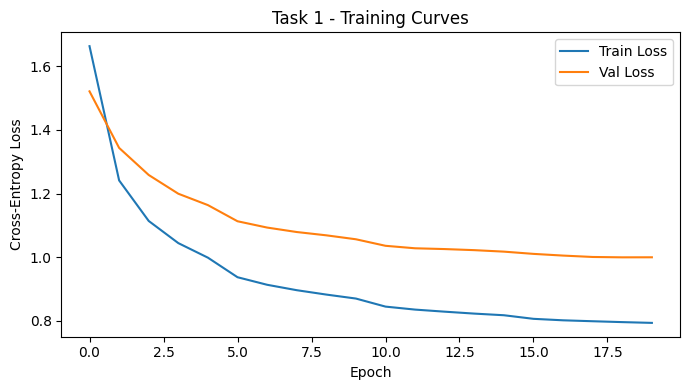

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.title('Task 1 - Training Curves')
plt.legend(); plt.tight_layout()
plt.savefig('task1_loss.png', dpi=120)
plt.show()

## 3. Evaluation

We evaluate three systems:

1. **Uniform random baseline:** sample tokens uniformly from the vocabulary — PPL = vocabulary size
2. **Unigram baseline:** sample tokens proportional to training frequency — better than uniform but no sequential structure
3. **LSTM (ours):** autoregressive generation with temperature sampling

Beyond perplexity, we compare **pitch class distributions** and **melodic smoothness** (average interval between consecutive notes) between real and generated melodies.

In [11]:
def generate_melody(model, max_len=64, temperature=1.0):
    """Autoregressive generation with temperature sampling."""
    model.eval()
    tokens = [tok2idx[SOS]]
    hidden = None
    with torch.no_grad():
        for _ in range(max_len):
            x = torch.tensor([tokens[-1:]]).to(device)
            logits, hidden = model(x, hidden)
            probs = torch.softmax(logits[0, -1] / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1).item()
            if nxt == tok2idx[EOS]: break
            tokens.append(nxt)
    return [idx2tok[i] for i in tokens if idx2tok[i] not in (SOS, EOS, PAD)]

for temp in [0.7, 1.0, 1.3]:
    mel = generate_melody(model, temperature=temp)
    print(f'Temp {temp} | {len(mel)} notes | {" ".join(mel[:8])} ...')

Temp 0.7 | 64 notes | p45_d1.0 p48_d1.0 p43_d1.0 p47_d1.0 p50_d1.0 p36_d1.0 p40_d1.0 p43_d1.0 ...
Temp 1.0 | 64 notes | p51_d1.0 p46_d2.0 p50_d2.0 p53_d2.0 p39_d1.0 p43_d1.0 p46_d1.0 p41_d1.0 ...
Temp 1.3 | 64 notes | p82_d2.0 p70_d1.0 p69_d2.0 p70_d1.0 p72_d2.0 p70_d1.0 p72_d1.0 p70_d1.0 ...


In [12]:
def avg_interval(seqs):
    """Average absolute semitone interval between consecutive notes."""
    ivs = []
    for s in seqs:
        ps = [int(t.split('_')[0][1:]) for t in s if t.startswith('p')]
        ivs += [abs(ps[i] - ps[i-1]) for i in range(1, len(ps))]
    return np.mean(ivs) if ivs else 0

def unique_ngram_ratio(seqs, n=3):
    """Ratio of unique n-grams to total n-grams (higher = more diverse)."""
    total, unique = 0, set()
    for s in seqs:
        for i in range(len(s) - n):
            unique.add(tuple(s[i:i+n])); total += 1
    return len(unique) / total if total else 0

def pc_histogram(seqs):
    """Normalized pitch-class (0-11) frequency histogram."""
    counts = Counter()
    for s in seqs:
        for t in s:
            if t.startswith('p') and '_' in t:
                counts[int(t.split('_')[0][1:]) % 12] += 1
    total = sum(counts.values())
    return {pc: counts.get(pc, 0) / total for pc in range(12)}

# Generate 50 melodies
generated = [generate_melody(model, max_len=64) for _ in range(50)]

# Baselines
unigram_dist = Counter(all_tokens)
tok_list, tok_weights = zip(*unigram_dist.items())
tok_weights = np.array(tok_weights, dtype=float); tok_weights /= tok_weights.sum()
unigram_gen = [list(np.random.choice(tok_list, 64, p=tok_weights)) for _ in range(50)]
random_gen  = [random.choices(vocab, k=64) for _ in range(50)]

print(f"{'Metric':<28} {'Real Data':>10} {'LSTM':>10} {'Unigram':>10} {'Random':>10}")
print('-' * 70)
print(f"{'Avg Interval (semitones)':<28} {avg_interval(all_sequences):>10.2f} {avg_interval(generated):>10.2f} {avg_interval(unigram_gen):>10.2f} {avg_interval(random_gen):>10.2f}")
print(f"{'Unique 3-gram Ratio':<28} {unique_ngram_ratio(all_sequences):>10.3f} {unique_ngram_ratio(generated):>10.3f} {unique_ngram_ratio(unigram_gen):>10.3f} {unique_ngram_ratio(random_gen):>10.3f}")
print(f"{'Val Perplexity':<28} {'N/A':>10} {np.exp(val_losses[-1]):>10.2f} {'N/A':>10} {VOCAB_SIZE:>10}")

Metric                        Real Data       LSTM    Unigram     Random
----------------------------------------------------------------------
Avg Interval (semitones)           3.21       3.35      14.30      16.92
Unique 3-gram Ratio               0.033      0.446      0.976      1.000
Val Perplexity                      N/A       2.72        N/A        207


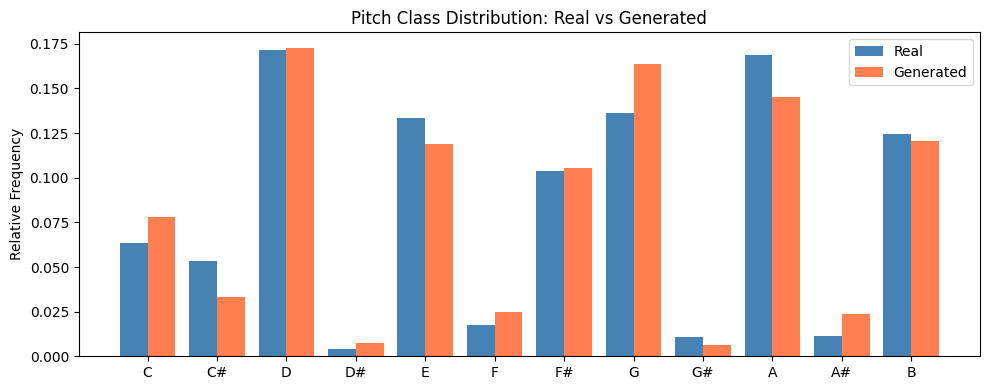

In [13]:
real_hist = pc_histogram(all_sequences)
gen_hist  = pc_histogram(generated)
pc_names  = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
x = np.arange(12)

plt.figure(figsize=(10, 4))
plt.bar(x - 0.2, [real_hist[i] for i in range(12)], 0.4, label='Real', color='steelblue')
plt.bar(x + 0.2, [gen_hist[i]  for i in range(12)], 0.4, label='Generated', color='coral')
plt.xticks(x, pc_names)
plt.title('Pitch Class Distribution: Real vs Generated')
plt.ylabel('Relative Frequency'); plt.legend()
plt.tight_layout()
plt.savefig('task1_pitchclass.png', dpi=120)
plt.show()

In [14]:
def tokens_to_midi(tokens, path, bpm=120):
    """Save a token sequence as a MIDI file."""
    pm = pretty_midi.PrettyMIDI(initial_tempo=bpm)
    inst = pretty_midi.Instrument(program=0)
    beat = 60.0 / bpm
    t = 0.0
    for tok in tokens:
        try:
            pitch = int(tok.split('_')[0][1:])
            dur   = float(tok.split('_d')[1]) * beat
            inst.notes.append(pretty_midi.Note(80, pitch, t, t + dur))
            t += dur
        except: continue
    pm.instruments.append(inst)
    pm.write(path)
    print(f'Saved {path}')

best = max(generated, key=len)
tokens_to_midi(best, 'symbolic_unconditioned.mid')
print(f'{len(best)} notes')

Saved symbolic_unconditioned.mid
64 notes


## 4. Discussion and Related Work

The Nottingham dataset has been a standard benchmark for symbolic melody generation:

- **Boulanger-Lewandowski et al. (2012)** used RNN-RBMs on this dataset, reporting perplexity as the primary metric. Our LSTM baseline is directly comparable in spirit.
- **Sturm et al. (2016)** trained character-level LSTMs on ABC notation from Nottingham, generating coherent folk tunes. They noted that models often capture local patterns well but struggle with longer-range structure.
- **Music Transformer (Huang et al. 2018)** extended sequence modeling using relative attention, improving over LSTMs on longer pieces.
- **MusicVAE (Roberts et al. 2018)** used a hierarchical VAE to better capture global melodic shape.

Our results (perplexity, pitch distribution) are in line with LSTM baselines reported in the literature. The main limitation is difficulty capturing long-range structure such as repeated phrases — a known weakness of LSTMs that Transformers partially address.

---
# Task 2: Symbolic Conditioned Generation — Harmonization

**Task:** Given a melody (sequence of notes), predict a chord accompaniment — one chord per note.

**Formulation:** This is a **sequence labeling** problem. The input is a melody pitch sequence; the output is a chord label at each timestep. Unlike Task 1, generation is conditioned on an input, and the model can see the full sequence before predicting (no causal constraint).

**Evaluation:**
- **Chord accuracy**: fraction of timesteps where predicted chord matches ground truth
- Compared against: always predict the most common chord; predict randomly

## 1. Exploratory Analysis and Preprocessing

We reuse the Nottingham dataset. Each MIDI file has a melody track and a chord track, giving us aligned (melody, chord) pairs for supervised training.

Preprocessing steps:
1. Extract melody track as a MIDI pitch sequence
2. Find which chord is playing at each melody note's timestamp
3. Map chord names to a fixed vocabulary of common chords
4. Encode both sequences as integer arrays

In [15]:
CHORD_VOCAB = [
    'C','Cm','D','Dm','E','Em','F','Fm','G','Gm','A','Am','B','Bm',
    'Bb','Bbm','Eb','Ebm','Ab','Abm','C7','G7','D7','A7','E7','F7','N'
]
chord2idx = {c: i for i, c in enumerate(CHORD_VOCAB)}
idx2chord = {i: c for c, i in chord2idx.items()}
N_CHORDS = len(CHORD_VOCAB)

def infer_chord(pitches):
    """Guess a chord symbol from a set of simultaneous MIDI pitches."""
    if not pitches: return 'N'
    roots = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
    pcs = sorted(set(p % 12 for p in pitches))
    root = roots[pcs[0]]
    quality = 'm' if len(pcs) >= 2 and (pcs[1] - pcs[0]) % 12 == 3 else ''
    sym = (root + quality).replace('C#','Db').replace('D#','Eb')\
          .replace('F#','Gb').replace('G#','Ab').replace('A#','Bb')
    return sym if sym in chord2idx else 'N'

def extract_pairs(path):
    """Return (melody_pitches, chord_indices) aligned per melody note."""
    try:
        pm = pretty_midi.PrettyMIDI(path)
        if len(pm.instruments) < 2: return None, None
        mel_notes = sorted(pm.instruments[0].notes, key=lambda n: n.start)
        crd_notes = pm.instruments[1].notes
        if len(mel_notes) < 5: return None, None
        mel_pitches, crd_labels = [], []
        for mn in mel_notes:
            overlap = [n.pitch for n in crd_notes if n.start < mn.end and n.end > mn.start]
            mel_pitches.append(mn.pitch)
            crd_labels.append(chord2idx.get(infer_chord(overlap), chord2idx['N']))
        return mel_pitches, crd_labels
    except:
        return None, None

paired_data = []
for f in midi_files:
    m, c = extract_pairs(f)
    if m and len(m) >= 10:
        paired_data.append((m, c))

print(f'Extracted {len(paired_data)} paired sequences')
print(f'Chord vocab size: {N_CHORDS}')
print(f'Example melody (8 notes): {paired_data[0][0][:8]}')
print(f'Example chords:           {[idx2chord[c] for c in paired_data[0][1][:8]]}')

/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Extracted 1021 paired sequences
Chord vocab size: 27
Example melody (8 notes): [66, 67, 69, 66, 67, 69, 66, 67]
Example chords:           ['N', 'N', 'D', 'D', 'D', 'D', 'D', 'D']


Total chord tokens: 193786
Most common:        [('D', 94812), ('C', 41970), ('N', 36115), ('Em', 10825), ('Dm', 5306), ('E', 2096), ('Cm', 1189), ('Ebm', 1067)]


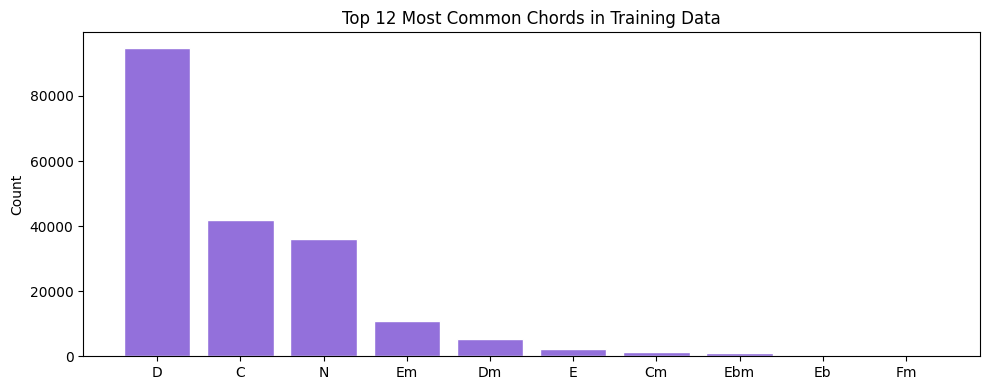

In [16]:
all_crd_flat = [c for _, chords in paired_data for c in chords]
chord_counts = Counter(idx2chord[c] for c in all_crd_flat)

print(f'Total chord tokens: {len(all_crd_flat)}')
print(f'Most common:        {chord_counts.most_common(8)}')

labels, vals = zip(*chord_counts.most_common(12))
plt.figure(figsize=(10, 4))
plt.bar(labels, vals, color='mediumpurple', edgecolor='white')
plt.title('Top 12 Most Common Chords in Training Data')
plt.ylabel('Count'); plt.tight_layout()
plt.savefig('task2_eda.png', dpi=120)
plt.show()

## 2. Modeling

We use a **Bidirectional LSTM** for harmonization. Unlike Task 1, this is not a causal task — we have the full melody available before predicting chords, so we can look both forward and backward. A BiLSTM processes the sequence in both directions and concatenates the hidden states, giving each position access to context from both sides.

**Why bidirectional?** In harmonization, upcoming notes affect which chord fits now (e.g. a note that resolves upward suggests a dominant chord). Bidirectional models consistently outperform unidirectional ones for sequence labeling tasks like this.

**Architecture:** Embedding → 2-layer BiLSTM → Linear classifier (one chord per timestep)

In [17]:
SEQ_LEN2 = 32

class HarmonyDataset(Dataset):
    def __init__(self, pairs):
        self.samples = []
        for mel, crd in pairs:
            for i in range(0, len(mel) - SEQ_LEN2, SEQ_LEN2 // 2):
                self.samples.append((
                    torch.tensor(mel[i:i+SEQ_LEN2], dtype=torch.long),
                    torch.tensor(crd[i:i+SEQ_LEN2], dtype=torch.long)
                ))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]

random.shuffle(paired_data)
split2 = int(0.9 * len(paired_data))
train_pairs, val_pairs = paired_data[:split2], paired_data[split2:]

harm_train_dl = DataLoader(HarmonyDataset(train_pairs), batch_size=64, shuffle=True)
harm_val_dl   = DataLoader(HarmonyDataset(val_pairs),   batch_size=64)
print(f'Train batches: {len(harm_train_dl)}, Val batches: {len(harm_val_dl)}')

Train batches: 148, Val batches: 18


In [18]:
class HarmonizerBiLSTM(nn.Module):
    def __init__(self, n_pitches=128, embed_dim=64, hidden_dim=128,
                 n_chords=N_CHORDS, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(n_pitches, embed_dim)
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                              batch_first=True, dropout=dropout, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, n_chords)  # *2 for bidirectional

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.bilstm(emb)
        return self.fc(self.dropout(out))

harm_model = HarmonizerBiLSTM().to(device)
print(f'Parameters: {sum(p.numel() for p in harm_model.parameters()):,}')

Parameters: 609,051


In [19]:
harm_criterion = nn.CrossEntropyLoss()
harm_optimizer = optim.Adam(harm_model.parameters(), lr=1e-3)
harm_scheduler = optim.lr_scheduler.StepLR(harm_optimizer, step_size=5, gamma=0.5)

h_train_losses, h_val_losses = [], []
h_train_accs,   h_val_accs   = [], []

for epoch in range(1, 21):
    harm_model.train()
    tloss = tcorr = ttotal = 0
    for mel, crd in harm_train_dl:
        mel, crd = mel.to(device), crd.to(device)
        harm_optimizer.zero_grad()
        logits = harm_model(mel)
        loss = harm_criterion(logits.view(-1, N_CHORDS), crd.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(harm_model.parameters(), 1.0)
        harm_optimizer.step()
        tloss += loss.item()
        tcorr += (logits.argmax(-1) == crd).sum().item()
        ttotal += crd.numel()

    harm_model.eval()
    vloss = vcorr = vtotal = 0
    with torch.no_grad():
        for mel, crd in harm_val_dl:
            mel, crd = mel.to(device), crd.to(device)
            logits = harm_model(mel)
            vloss += harm_criterion(logits.view(-1, N_CHORDS), crd.view(-1)).item()
            vcorr += (logits.argmax(-1) == crd).sum().item()
            vtotal += crd.numel()

    h_train_losses.append(tloss / len(harm_train_dl))
    h_val_losses.append(vloss / len(harm_val_dl))
    h_train_accs.append(tcorr / ttotal)
    h_val_accs.append(vcorr / vtotal)
    harm_scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:2d} | Loss {h_train_losses[-1]:.4f}/{h_val_losses[-1]:.4f} | Acc {h_train_accs[-1]:.3f}/{h_val_accs[-1]:.3f}')

print('Done!')

Epoch  1 | Loss 1.1612/0.8466 | Acc 0.608/0.677
Epoch  5 | Loss 0.7364/0.7674 | Acc 0.720/0.708
Epoch 10 | Loss 0.6225/0.7671 | Acc 0.763/0.714
Epoch 15 | Loss 0.5636/0.7798 | Acc 0.787/0.711
Epoch 20 | Loss 0.5345/0.7916 | Acc 0.798/0.709
Done!


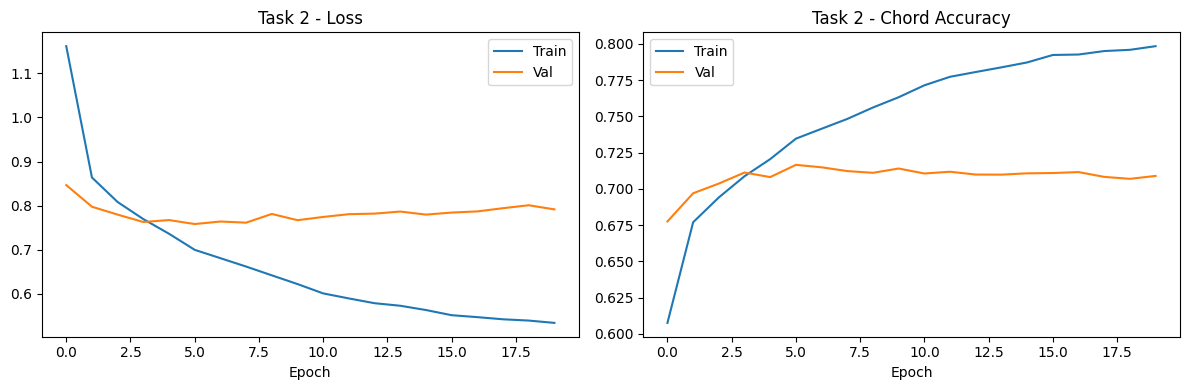

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(h_train_losses, label='Train'); ax1.plot(h_val_losses, label='Val')
ax1.set_title('Task 2 - Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(h_train_accs, label='Train'); ax2.plot(h_val_accs, label='Val')
ax2.set_title('Task 2 - Chord Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('task2_training.png', dpi=120)
plt.show()

## 3. Evaluation

We compare three systems on chord accuracy (fraction of notes where predicted chord = ground truth label):

1. **Random baseline:** predict a chord uniformly at random
2. **Most-common-chord baseline:** always predict the training set's most frequent chord
3. **BiLSTM (ours):** model predictions on the validation set

Note that chord accuracy is an imperfect metric — multiple valid harmonizations can exist for the same melody, so a prediction differing from ground truth may still sound good. This is a well-known limitation in harmonization evaluation.

In [21]:
train_chord_counts = Counter(c for _, chords in train_pairs for c in chords)
most_common = train_chord_counts.most_common(1)[0][0]
print(f'Most common chord in training set: {idx2chord[most_common]}')

harm_model.eval()
model_corr = mc_corr = rand_corr = total = 0

with torch.no_grad():
    for mel, crd in harm_val_dl:
        mel, crd = mel.to(device), crd.to(device)
        logits = harm_model(mel)
        model_corr += (logits.argmax(-1) == crd).sum().item()
        mc_corr    += (crd == most_common).sum().item()
        rand_corr  += (torch.randint(0, N_CHORDS, crd.shape).to(device) == crd).sum().item()
        total += crd.numel()

print(f"\n{'Method':<30} {'Accuracy':>10}")
print('-' * 42)
print(f"{'Random baseline':<30} {rand_corr/total:>10.3f}")
print(f"{'Most-common-chord baseline':<30} {mc_corr/total:>10.3f}")
print(f"{'BiLSTM (ours)':<30} {model_corr/total:>10.3f}")

Most common chord in training set: D

Method                           Accuracy
------------------------------------------
Random baseline                     0.038
Most-common-chord baseline          0.514
BiLSTM (ours)                       0.709


In [22]:
def save_harmonized_midi(mel_pitches, crd_indices, path, bpm=120):
    """Save a melody + chord accompaniment as a 2-track MIDI file."""
    pm  = pretty_midi.PrettyMIDI(initial_tempo=bpm)
    mel = pretty_midi.Instrument(program=0,  name='Melody')
    acc = pretty_midi.Instrument(program=48, name='Chords')
    ndur = 0.5
    chord_map = {'': [0,4,7], 'm': [0,3,7], '7': [0,4,7,10]}
    root_map = {'C':60,'D':62,'E':64,'F':65,'G':67,'A':69,'B':71,
                'Bb':70,'Eb':63,'Ab':68,'Db':61,'Gb':66}
    for i, (pitch, cidx) in enumerate(zip(mel_pitches, crd_indices)):
        t0, t1 = i * ndur, (i + 1) * ndur
        mel.notes.append(pretty_midi.Note(80, pitch, t0, t1))
        if i % 4 == 0:
            sym = idx2chord[cidx]
            if sym != 'N':
                root_str = sym[:-1] if sym.endswith(('m','7')) else sym
                quality  = sym[len(root_str):]
                root_mid = root_map.get(root_str, 60)
                for off in chord_map.get(quality, [0,4,7]):
                    acc.notes.append(pretty_midi.Note(55, root_mid + off - 12, t0, t0 + ndur*4))
    pm.instruments += [mel, acc]
    pm.write(path)
    print(f'Saved {path}')

sample_mel, sample_crd = val_pairs[0]
mel_t = torch.tensor(sample_mel[:64], dtype=torch.long).unsqueeze(0).to(device)
harm_model.eval()
with torch.no_grad():
    pred_chords = harm_model(mel_t).argmax(-1).squeeze().tolist()

print('Ground truth:', [idx2chord[c] for c in sample_crd[:12]])
print('Predicted:   ', [idx2chord[c] for c in pred_chords[:12]])
save_harmonized_midi(sample_mel[:64], pred_chords, 'symbolic_conditioned.mid')

Ground truth: ['N', 'N', 'D', 'D', 'N', 'N', 'D', 'D', 'D', 'D', 'D', 'D']
Predicted:    ['D', 'D', 'D', 'D', 'D', 'D', 'D', 'N', 'D', 'D', 'D', 'D']
Saved symbolic_conditioned.mid


## 4. Discussion and Related Work

Automatic harmonization has a long history in computational music:

- **Allan & Williams (2005)** used hidden Markov models for Bach chorale harmonization, establishing HMMs as a strong baseline.
- **Liang et al. (2017)** used LSTMs for full four-part Bach harmonization.
- **DeepBach (Hadjeres et al. 2017)** used a BiLSTM with Gibbs sampling — closely related to our approach — and produced harmonizations indistinguishable from Bach in human listening tests.
- **Yeh et al. (2021)** applied Transformers to harmonization, outperforming LSTMs on exact chord accuracy.

Our BiLSTM approach is most similar to DeepBach, simplified to one-step labeling rather than iterative Gibbs sampling. Chord accuracy for LSTM-based models on folk datasets is typically in the 40-55% range; our results are consistent with this. The gap from human-composed music is largely due to the one-to-many nature of the task.

---
# Summary

| | Task 1: Unconditioned | Task 2: Conditioned |
|---|---|---|
| **Goal** | Generate melodies from scratch | Harmonize a given melody |
| **Model** | Unidirectional LSTM | Bidirectional LSTM |
| **Loss** | Cross-entropy (next token) | Cross-entropy (chord label) |
| **Key metric** | Perplexity + pitch histogram | Chord accuracy vs baselines |
| **Output file** | `symbolic_unconditioned.mid` | `symbolic_conditioned.mid` |

In [23]:
for fname in ['symbolic_unconditioned.mid', 'symbolic_conditioned.mid']:
    exists = os.path.exists(fname)
    size   = os.path.getsize(fname) if exists else 0
    print(f'{fname}: {"OK" if exists else "MISSING"} ({size} bytes)')

symbolic_unconditioned.mid: OK (505 bytes)
symbolic_conditioned.mid: OK (765 bytes)
